In [60]:
import torch

In [61]:
words = open('names.txt', 'r').read().splitlines()

In [72]:
N = torch.zeros((27, 27), dtype=torch.int32)
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}

for w in words:
  chs = ['.'] + list(w) + ['.']
  for ch1, ch2 in zip(chs, chs[1:]):
    ix1 = stoi[ch1]
    ix2 = stoi[ch2]
    N[ix1, ix2] += 1

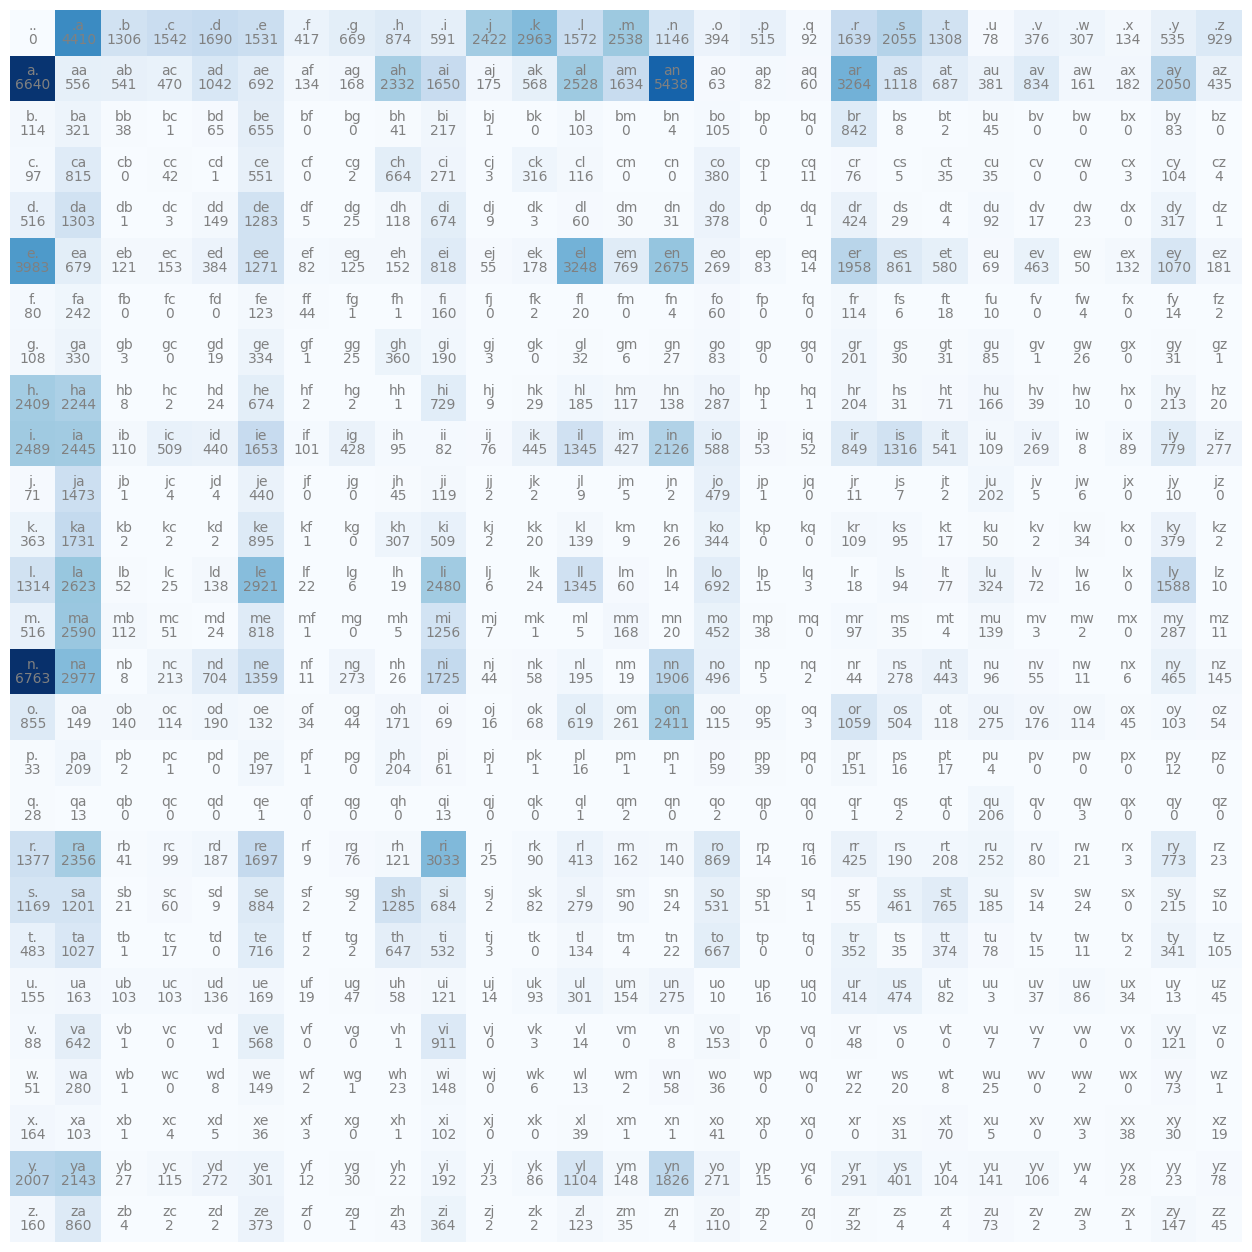

In [73]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.figure(figsize=(16,16))
plt.imshow(N, cmap='Blues')
for i in range(27):
    for j in range(27):
        chstr = itos[i] + itos[j]
        plt.text(j, i, chstr, ha="center", va="bottom", color='gray')
        plt.text(j, i, N[i, j].item(), ha="center", va="top", color='gray')
plt.axis('off');

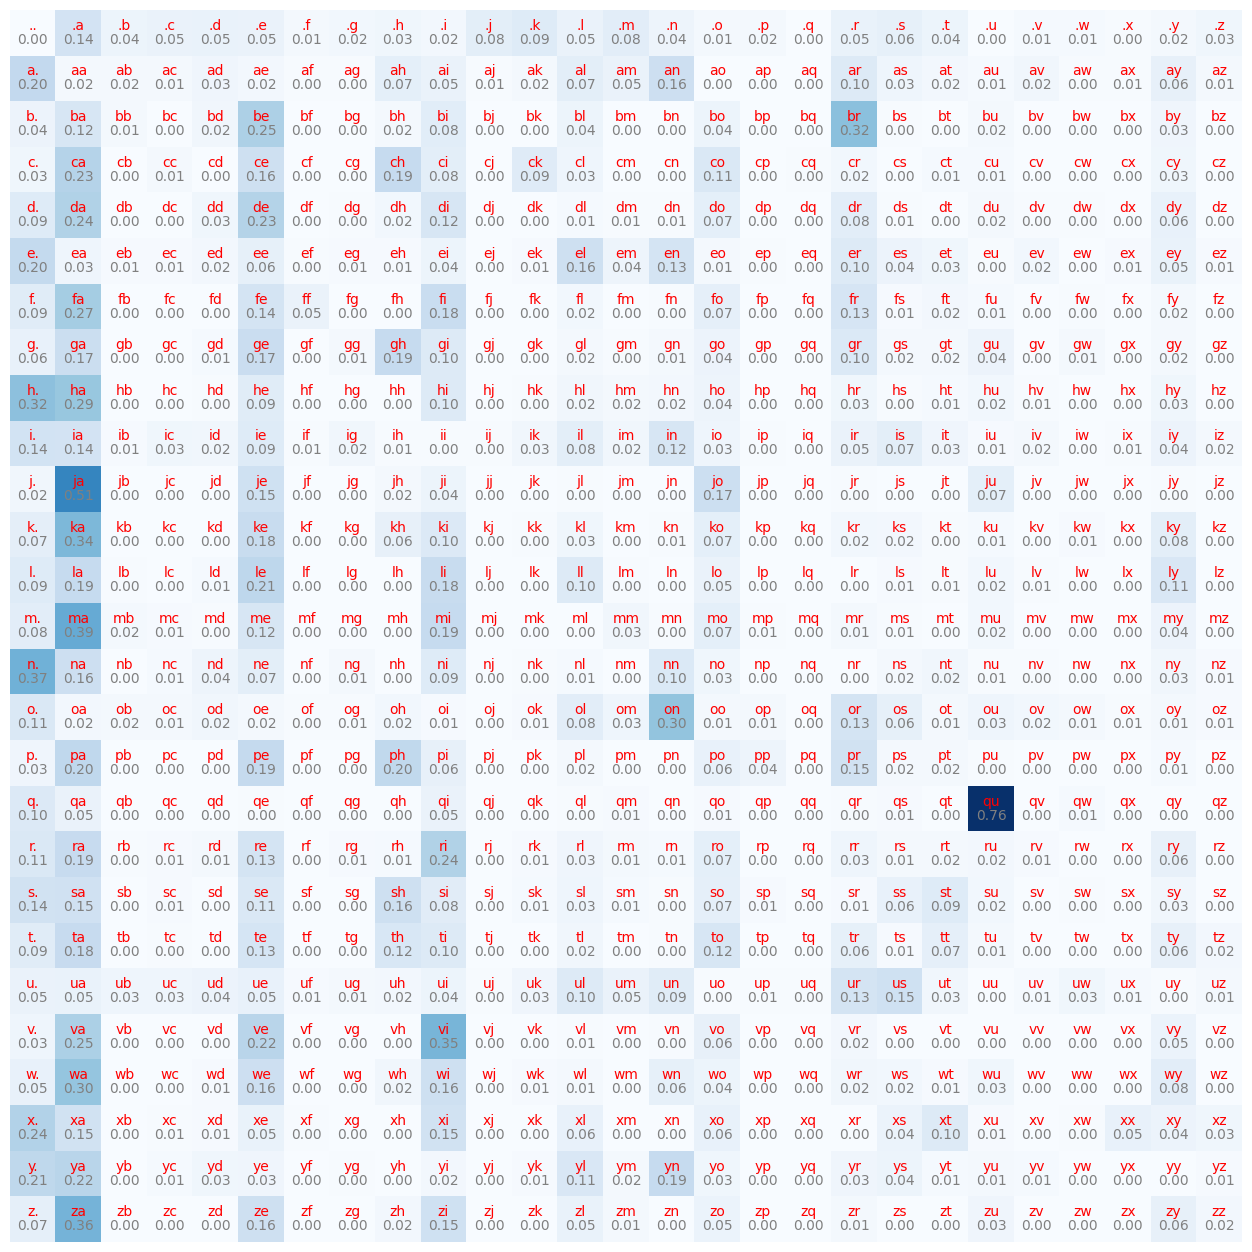

In [74]:
#probility distribution
P = N / N.sum(1, keepdims=True)# sum dimension 1, sum of the rows, keepdims to keep the dimension of the result the same as N
plt.figure(figsize=(16,16))
plt.imshow(P, cmap='Blues')
for i in range(27):
    for j in range(27):
        chstr = itos[i] + itos[j]
        plt.text(j, i, chstr, ha="center", va="bottom", color='red')
        plt.text(j, i, f"{P[i, j].item():.2f}", ha="center", va="top", color='gray')
plt.axis('off');

In [48]:
g = torch.Generator().manual_seed(2147483647)
p = P[0]
ix = torch.multinomial(p, num_samples=5, replacement=True, generator=g)
# convert sampled indices to characters
[s for s in [itos[i.item()] for i in ix]]

['m', 's', 'n', 'a', 'a']

In [50]:
g = torch.Generator().manual_seed(2147483647)

for i in range(5):
  
  out = []
  ix = 0
  while True:
    p = P[ix]
    ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
    out.append(itos[ix])
    if ix == 0:
      break
  print(''.join(out))

junide.
janasah.
p.
cony.
a.


In [75]:
g = torch.Generator().manual_seed(2147483647)

for i in range(10):
    out = []
    ix = 0 # start from the start token character
    while True:
        p = N[ix].float()
        p = p / p.sum()
        #p = torch.ones(27)/ 27.0
        ix = torch.multinomial(p,num_samples=1, replacement = True, generator = g).item()
        #print(itos[ix], end ='')
        out.append(itos[ix])
        if ix == 0: # If it is the end token character break the loop
            break
    print("".join(out))

junide.
janasah.
p.
cony.
a.
nn.
kohin.
tolian.
juee.
ksahnaauranilevias.


In [78]:
# GOAL: maximize likelihood of the data w.r.t. model parameters (statistical modeling)
# equivalent to maximizing the log likelihood (because log is monotonic)
# equivalent to minimizing the negative log likelihood
# equivalent to minimizing the average negative log likelihood

# log(a*b*c) = log(a) + log(b) + log(c)
P = N.float()
P /= P.sum(1, keepdim=True)
P[0].sum()

for w in words[:3]:
    chs = ['.'] + list(w) + ['.'] 
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        prob = P[ix1, ix2]
        print(f'{ch1}{ch2}: {prob:.4f}')

.e: 0.0478
em: 0.0377
mm: 0.0253
ma: 0.3899
a.: 0.1960
.o: 0.0123
ol: 0.0780
li: 0.1777
iv: 0.0152
vi: 0.3541
ia: 0.1381
a.: 0.1960
.a: 0.1377
av: 0.0246
va: 0.2495
a.: 0.1960


In [83]:
log_likelihood = 0.0
n = 0
for w in words[:3]:
    chs = ['.'] + list(w) + ['.'] 
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        prob = P[ix1, ix2]
        logprob = torch.log(prob)
        log_likelihood += logprob
        n += 1
        print(f'{ch1}{ch2}: {prob:.4f} {logprob:.4f}')
        
print(f'\nlog_likelihood = {log_likelihood:.4f}')
nll = -log_likelihood
print(f'negative log_likelihood = {nll:.4f}')
avg_nll = nll/n
print(f'average negative log_likelihood = {avg_nll:.4f}')

.e: 0.0478 -3.0408
em: 0.0377 -3.2793
mm: 0.0253 -3.6772
ma: 0.3899 -0.9418
a.: 0.1960 -1.6299
.o: 0.0123 -4.3982
ol: 0.0780 -2.5508
li: 0.1777 -1.7278
iv: 0.0152 -4.1867
vi: 0.3541 -1.0383
ia: 0.1381 -1.9796
a.: 0.1960 -1.6299
.a: 0.1377 -1.9829
av: 0.0246 -3.7045
va: 0.2495 -1.3882
a.: 0.1960 -1.6299

log_likelihood = -38.7856
negative log_likelihood = 38.7856
average negative log_likelihood = 2.4241


Our loss function (avg_nll) for the training set's first three words assigned by the model is 2.42.
The lower the loss function, the better the model quality and vice-versa.

In [ ]:
#Now let's estimate the average NLL (avg_nll) over the entire dataset:
log_likelihood = 0.0
n = 0
for w in words:
    chs = ['.'] + list(w) + ['.'] 
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        prob = P[ix1, ix2]
        logprob = torch.log(prob)
        log_likelihood += logprob
        n += 1
        #print(f'{ch1}{ch2}: {prob:.4f} {logprob:.4f}')
        
print(f'\nTotal log_likelihood = {log_likelihood:.4f}')
nll = -log_likelihood
print(f'nTotal negative log_likelihood = {nll:.4f}')
avg_nll = nll/n
print(f'nTotal average negative log_likelihood = {avg_nll:.4f}')

#Our loss function for the entire training set assigned by the model is 2.45.

#However, we can evaluate the probability for any word we want.
log_likelihood = 0.0
n = 0
for w in ["andrej"]:
    chs = ['.'] + list(w) + ['.'] 
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        prob = P[ix1, ix2]
        logprob = torch.log(prob)
        log_likelihood += logprob
        n += 1
        print(f'{ch1}{ch2}: {prob:.4f} {logprob:.4f}')
        
print(f'\nandrej log_likelihood = {log_likelihood:.4f}')
nll = -log_likelihood
print(f'andrej negative log_likelihood = {nll:.4f}')
avg_nll = nll/n
print(f'andrej average negative log_likelihood = {avg_nll:.4f}')

#Our loss function for the name Andrej assigned by the model is 
#Andrej is an unlikely name on average because ej bigram is very uncommon. 
#Let's look at an extreme case.




Total log_likelihood = -559891.7500
nTotal negative log_likelihood = 559891.7500
nTotal average negative log_likelihood = 2.4541
.a: 0.1377 -1.9829
an: 0.1605 -1.8296
nd: 0.0384 -3.2594
dr: 0.0771 -2.5620
re: 0.1336 -2.0127
ej: 0.0027 -5.9171
j.: 0.0245 -3.7098

andrej log_likelihood = -21.2735
andrej negative log_likelihood = 21.2735
andrej average negative log_likelihood = 3.0391


In [98]:
# Our loss function for the name Andrejq assigned by the model is infinitive.
# "Andrejq" is 0% likely to be predicted by the model because jq bigram is not in the dataset (prob = 0%). 
# This is not ideal (getting inf) so we apply model smoothing, which adds a constant value to every count in the N matrix before calculating the P matrix. 
# Hence, there are no more zeros in a probability matrix P. The higher the constant value (N+1000) added, 
# the more uniform the model is, and the lower the constant value added (N+1), the more peaked the model is. 
# In probability & statistics, this is called laplace smoothing.
P = (N+1).float()
P /= P.sum(1, keepdim=True)

#probility distribution
# P = N / N.sum(1, keepdims=True)# sum dimension 1, sum of the rows, keepdims to keep the dimension of the result the same as N
# plt.figure(figsize=(16,16))
# plt.imshow(P, cmap='Blues')
# for i in range(27):
#     for j in range(27):
#         chstr = itos[i] + itos[j]
#         plt.text(j, i, chstr, ha="center", va="bottom", color='red')
#         plt.text(j, i, f"{P[i, j].item():.2f}", ha="center", va="top", color='gray')
# plt.axis('off');

log_likelihood = 0.0
n = 0
for w in ["andrejq"]:
    chs = ['.'] + list(w) + ['.'] 
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1]
        ix2 = stoi[ch2]
        prob = P[ix1, ix2]
        logprob = torch.log(prob)
        log_likelihood += logprob
        n += 1
        print(f'{ch1}{ch2}: {prob:.4f} {logprob:.4f}')
        
print(f'\nlog_likelihood = {log_likelihood:.4f}')
nll = -log_likelihood
print(f'negative log_likelihood = {nll:.4f}')
avg_nll = nll/n
print(f'average negative log_likelihood = {avg_nll:.4f}')

.a: 0.1376 -1.9835
an: 0.1604 -1.8302
nd: 0.0384 -3.2594
dr: 0.0770 -2.5646
re: 0.1334 -2.0143
ej: 0.0027 -5.9004
jq: 0.0003 -7.9817
q.: 0.0970 -2.3331

log_likelihood = -27.8672
negative log_likelihood = 27.8672
average negative log_likelihood = 3.4834
